
=== V01: μ=0.25, vent=(678290, 3531350) ===


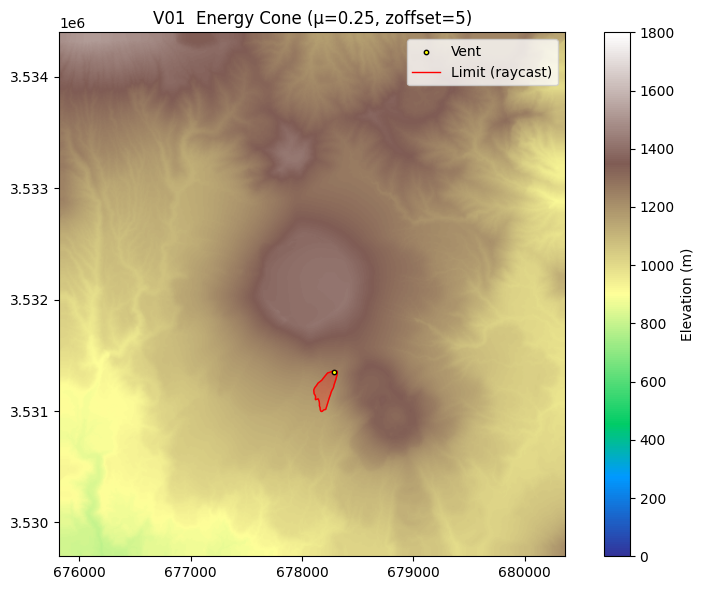

  ✅ PNG → energy_cone_mu_0.25_raycast/V01_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V01/V01_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V01/V01_mu_0.25_boundary.shp

=== V02: μ=0.25, vent=(677480, 3530970) ===


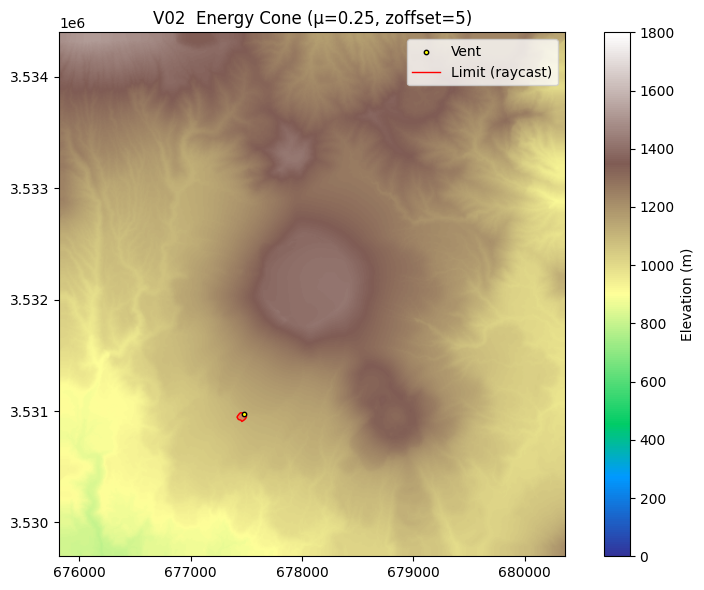

  ✅ PNG → energy_cone_mu_0.25_raycast/V02_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V02/V02_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V02/V02_mu_0.25_boundary.shp

=== V03: μ=0.25, vent=(677430, 3531860) ===


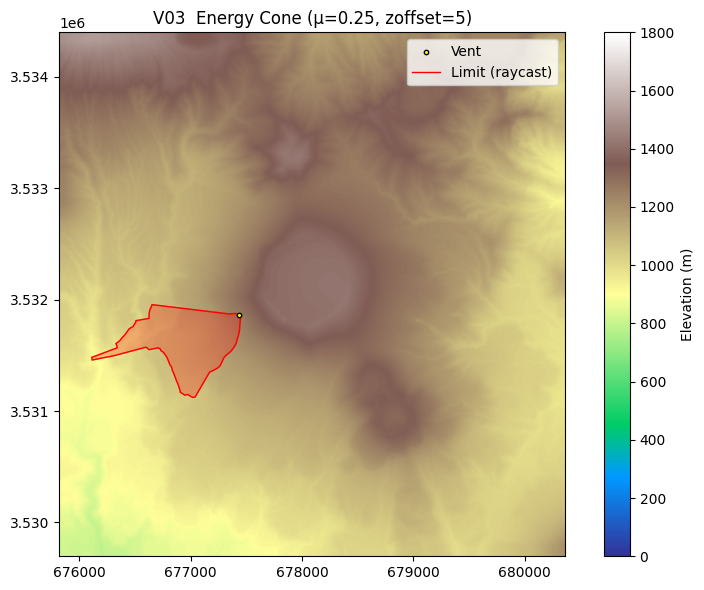

  ✅ PNG → energy_cone_mu_0.25_raycast/V03_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V03/V03_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V03/V03_mu_0.25_boundary.shp

=== V04: μ=0.25, vent=(678210, 3532520) ===


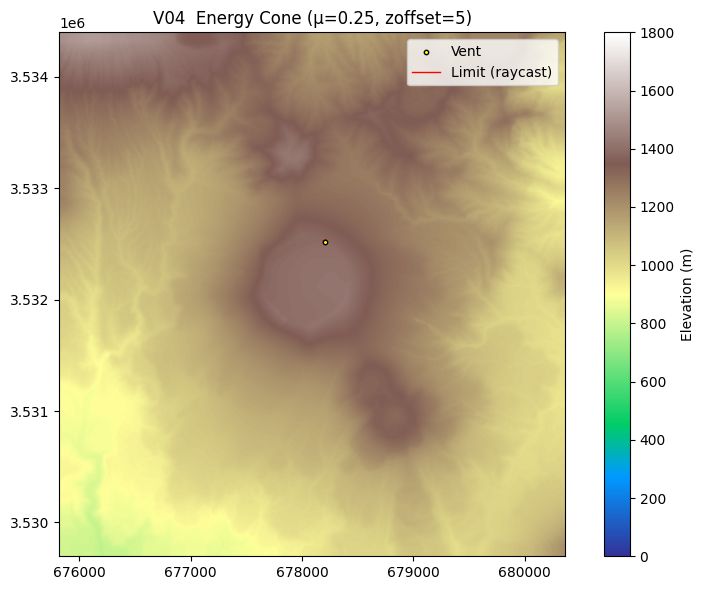

  ✅ PNG → energy_cone_mu_0.25_raycast/V04_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V04/V04_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V04/V04_mu_0.25_boundary.shp

=== V05: μ=0.25, vent=(678690, 3532250) ===


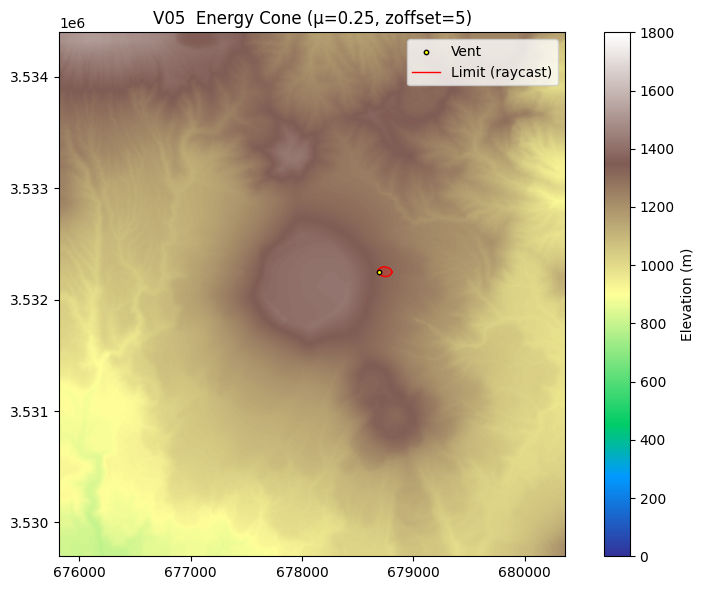

  ✅ PNG → energy_cone_mu_0.25_raycast/V05_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V05/V05_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V05/V05_mu_0.25_boundary.shp

=== V06: μ=0.25, vent=(677670, 3531820) ===


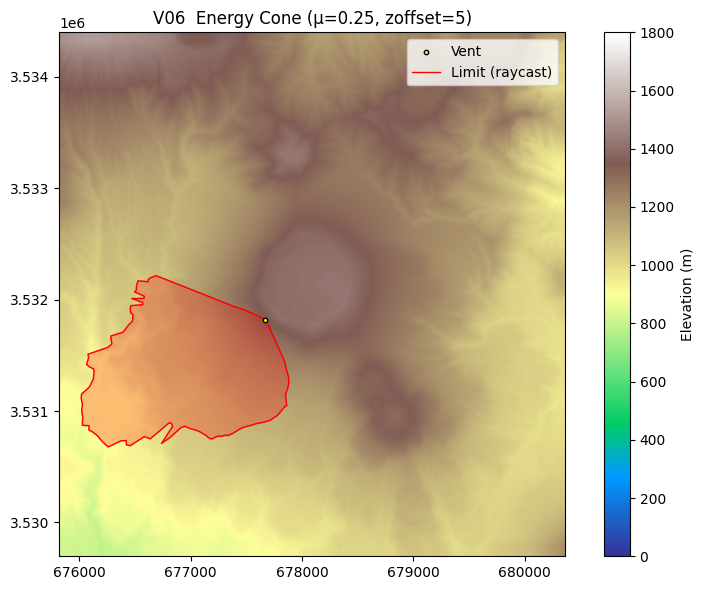

  ✅ PNG → energy_cone_mu_0.25_raycast/V06_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V06/V06_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V06/V06_mu_0.25_boundary.shp

=== V07: μ=0.25, vent=(676790, 3532190) ===


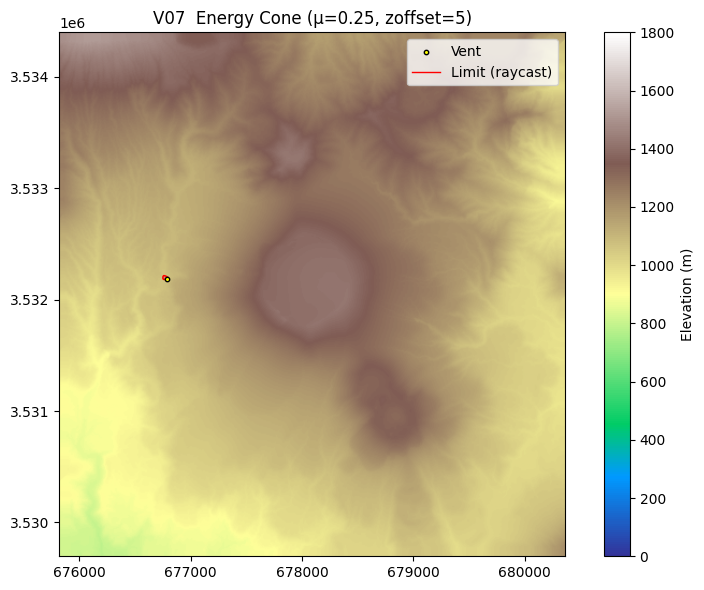

  ✅ PNG → energy_cone_mu_0.25_raycast/V07_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V07/V07_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V07/V07_mu_0.25_boundary.shp

=== V08: μ=0.25, vent=(676960, 3532510) ===


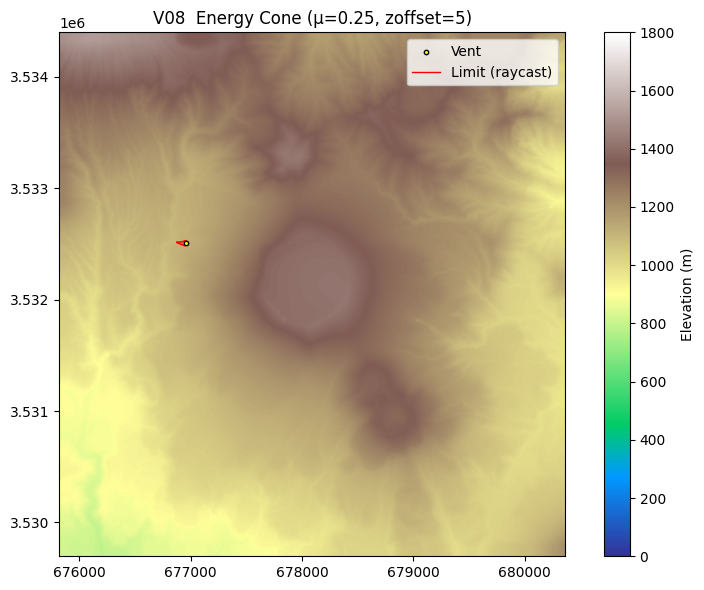

  ✅ PNG → energy_cone_mu_0.25_raycast/V08_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V08/V08_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V08/V08_mu_0.25_boundary.shp

=== V09: μ=0.25, vent=(678470, 3532040) ===


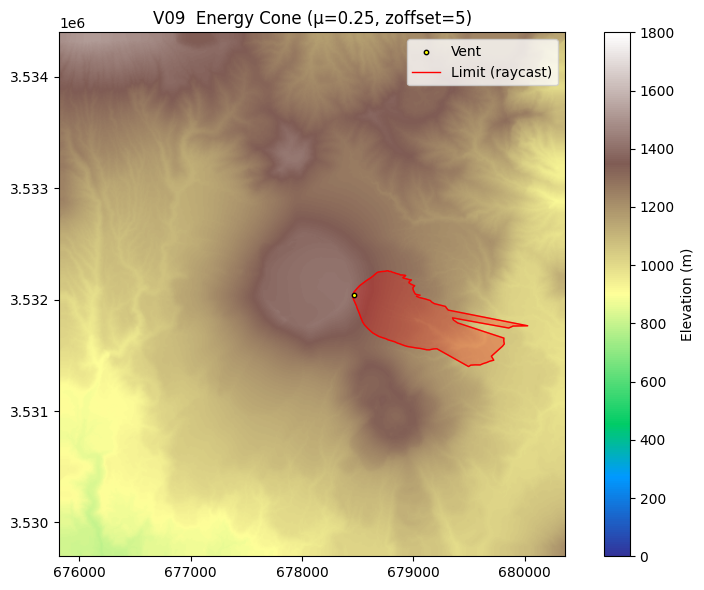

  ✅ PNG → energy_cone_mu_0.25_raycast/V09_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V09/V09_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V09/V09_mu_0.25_boundary.shp

=== V10: μ=0.25, vent=(678440, 3531830) ===


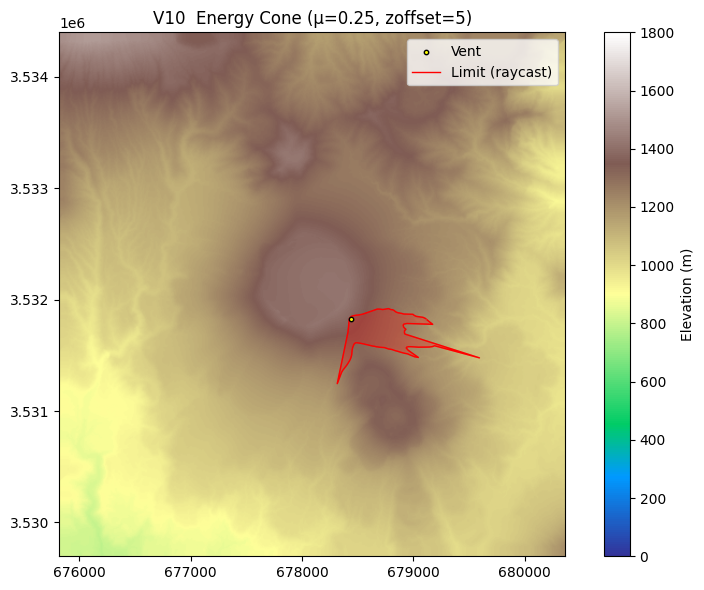

  ✅ PNG → energy_cone_mu_0.25_raycast/V10_mu_0.25.png
  ✅ Shapefile(points) → energy_cone_mu_0.25_raycast/V10/V10_mu_0.25_stops.shp
  ✅ Shapefile(polygon) → energy_cone_mu_0.25_raycast/V10/V10_mu_0.25_boundary.shp

✅ 全火口まとめ Shapefile（個別外縁の集合） → energy_cone_mu_0.25_raycast/all_vents_mu_0.25_boundaries.shp
✅ マージ Shapefile（全火口 union） → energy_cone_mu_0.25_raycast/merged_mu_0.25_union.shp
✅ サマリー CSV → energy_cone_mu_0.25_raycast/summary_mu_0.25.csv


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_46794/3667658554.py:259: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", 10)


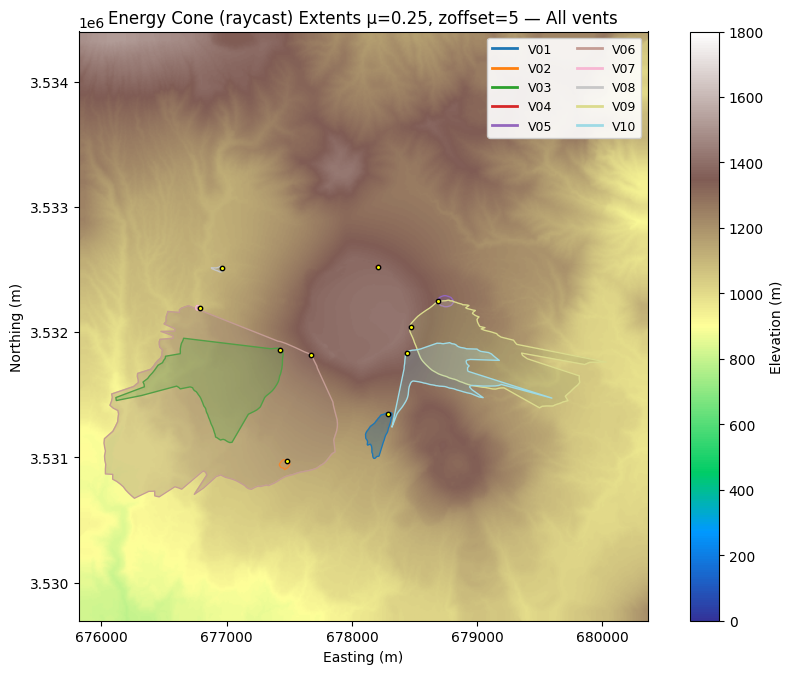

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import os, csv

# === 入力 ===
dem_file = "../demShinmoeRL2025S.tif"
mu = 0.30              # H/L = μ（tanθ）
zoffset = 5            # 立上げ高度 [m]（必要なら >0）
vents = [
    (678290, 3531350),
    (677480, 3530970),
    (677430, 3531860),
    (678210, 3532520),
    (678690, 3532250),
    (677670, 3531820),
    (676790, 3532190),
    (676960, 3532510),
    (678470, 3532040),
    (678440, 3531830),
]
crs_epsg = "EPSG:6689"  # JGD2011 / UTM zone 52N
az_step_deg = 1.0       # 方位刻み [deg]（2～5で高速化、1で滑らか）
# ステップ長 dr は DEM 解像度から自動算出（目安：ピクセルサイズ）
# 大きくすると速いが交点精度低下、小さくすると精度↑だが重くなる

# === DEM 読み込み（1回だけ）===
with rasterio.open(dem_file) as src:
    dem = src.read(1).astype(np.float32)
    transform = src.transform
    bounds = src.bounds
    invA = ~transform

rows, cols = dem.shape
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
# ピクセルサイズから dr を決める
px = (abs(transform.a) + abs(transform.e)) * 0.5  # 約10 m想定
dr = px

# === DEM バイリニア補間 ===
def sample_dem_bilinear(x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = dem[r0, c0]; z10 = dem[r0, c1]
    z01 = dem[r1, c0]; z11 = dem[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

# === レイキャスト本体：各方位の最初の交点を求めてポリゴン外縁を返す ===
def raycast_boundary_for_vent(x0, y0, mu, zoffset, az_step_deg=1.0, dr=10.0):
    # vent 標高
    col0, row0 = invA * (x0, y0)
    col0 = int(np.clip(np.floor(col0), 0, cols-1))
    row0 = int(np.clip(np.floor(row0), 0, rows-1))
    z0 = float(dem[row0, col0])

    # 画像外縁までの上限距離
    corners = [(extent[0], extent[2]), (extent[0], extent[3]),
               (extent[1], extent[2]), (extent[1], extent[3])]
    r_max_bound = max(np.hypot(x0 - cx, y0 - cy) for (cx, cy) in corners) + 2 * dr

    az_list = np.arange(0.0, 360.0, az_step_deg)
    stop_xy = []
    runouts = []

    # 初期値
    zt_prev = sample_dem_bilinear(x0, y0)
    zc_prev = z0 + zoffset

    for az in az_list:
        rad = np.deg2rad(az); dx = np.cos(rad); dy = np.sin(rad)
        r = 0.0
        zt_prev = sample_dem_bilinear(x0, y0)
        zc_prev = z0 + zoffset
        hit = None

        while r <= r_max_bound:
            r += dr
            x = x0 + r * dx
            y = y0 + r * dy

            zt = sample_dem_bilinear(x, y)
            if np.isnan(zt):
                break

            zc = z0 + zoffset - mu * r  # μ=H/L を直接使用

            if zt >= zc:
                # 線形補間で交点近似（サブピクセル）
                r1 = r - dr
                f0 = zc_prev - zt_prev
                f1 = zc - zt
                alpha = 0.0
                if (f0 - f1) != 0:
                    alpha = np.clip(f0 / (f0 - f1), 0.0, 1.0)
                r_star = r1 + alpha * dr
                x_star = x0 + r_star * dx
                y_star = y0 + r_star * dy
                hit = (x_star, y_star, r_star)
                break

            zc_prev, zt_prev = zc, zt

        if hit is None:
            # 交点なし：描画範囲端
            hit = (x, y, r)

        stop_xy.append((hit[0], hit[1]))
        runouts.append(hit[2])

    # 角度順の点列でポリゴン化
    poly = None
    pts = np.asarray(stop_xy)
    if len(pts) >= 3:
        poly = Polygon(pts)
        # 無効・自己交差の簡易修正（必要に応じて）
        if not poly.is_valid:
            poly = poly.buffer(0)

    return poly, az_list, np.array(runouts), z0

# === 出力用フォルダ ===
root_dir = f"energy_cone_mu_{mu:.2f}_raycast"
os.makedirs(root_dir, exist_ok=True)

# === まとめ出力 ===
per_vent_gdfs = []
summary_rows = []
summary_csv = os.path.join(root_dir, f"summary_mu_{mu:.2f}.csv")

# === 各火口を処理 ===
for i, (x0, y0) in enumerate(vents, start=1):
    vent_id = f"V{i:02d}"
    print(f"\n=== {vent_id}: μ={mu:.2f}, vent=({x0}, {y0}) ===")

    poly, az_list, runouts_m, z0 = raycast_boundary_for_vent(
        x0, y0, mu, zoffset, az_step_deg=az_step_deg, dr=dr
    )

    # PNG 描画
    plt.figure(figsize=(8, 6))
    im = plt.imshow(dem, cmap="terrain", extent=extent, origin="upper",
                    vmin=0, vmax=1800)
    plt.scatter([x0], [y0], c="yellow", s=10, edgecolor="black", zorder=11, label="Vent")
    # 停止点のリング（方位順）
    # runouts から停止点座標を再現
    xs = []; ys = []
    for az, r in zip(az_list, runouts_m):
        rad = np.deg2rad(az); xs.append(x0 + r*np.cos(rad)); ys.append(y0 + r*np.sin(rad))
    plt.plot(xs, ys, color="red", lw=1.0, label="Limit (raycast)")

    # 塗りつぶし
    if (poly is not None) and (not poly.is_empty):
        bx, by = poly.exterior.xy
        plt.fill(bx, by, color="red", alpha=0.25, zorder=5)

    plt.title(f"{vent_id}  Energy Cone (μ={mu:.2f}, zoffset={zoffset})")
    plt.colorbar(im, label="Elevation (m)")
    plt.legend()
    plt.tight_layout()
    png_file = os.path.join(root_dir, f"{vent_id}_mu_{mu:.2f}.png")
    plt.savefig(png_file, dpi=300)
    plt.show()
    print("  ✅ PNG →", png_file)

    # Shapefile（各 vent の外縁ポリゴン と 停止点）
    out_dir = os.path.join(root_dir, vent_id)
    os.makedirs(out_dir, exist_ok=True)

    # 停止点を Point として属性保存
    pts = []
    for az, r in zip(az_list, runouts_m):
        rad = np.deg2rad(az)
        px_, py_ = x0 + r*np.cos(rad), y0 + r*np.sin(rad)
        pts.append(Point(px_, py_))
    gdf_pts = gpd.GeoDataFrame(
        {"vent_id":[vent_id]*len(pts), "mu":[mu]*len(pts),
         "az_deg":az_list, "runout_m":runouts_m, "z0_m":[z0]*len(pts), "zoffset":[zoffset]*len(pts)},
        geometry=pts, crs=crs_epsg
    )
    shp_pts = os.path.join(out_dir, f"{vent_id}_mu_{mu:.2f}_stops.shp")
    gdf_pts.to_file(shp_pts)
    print("  ✅ Shapefile(points) →", shp_pts)

    # 外縁ポリゴン
    if (poly is not None) and (not poly.is_empty):
        gdf_poly = gpd.GeoDataFrame(
            {"vent_id":[vent_id], "mu":[mu], "z0_m":[z0], "zoffset":[zoffset]},
            geometry=[poly], crs=crs_epsg
        )
        shp_poly = os.path.join(out_dir, f"{vent_id}_mu_{mu:.2f}_boundary.shp")
        gdf_poly.to_file(shp_poly)
        print("  ✅ Shapefile(polygon) →", shp_poly)

        # 面積/Runout 指標
        area_km2 = float(gdf_poly.area.sum() / 1e6)
        runout_max_km = float(np.max(runouts_m) / 1000.0)
        runout_p95_km = float(np.percentile(runouts_m, 95) / 1000.0)

        per_vent_gdfs.append(gdf_poly)
        summary_rows.append([vent_id, x0, y0, mu, z0, runout_max_km, runout_p95_km, area_km2, 1])
    else:
        print("  ⚠ ポリゴンなし（交差が画外）")
        summary_rows.append([vent_id, x0, y0, mu, z0, 0.0, 0.0, 0.0, 0])

# === 全火口まとめ（個別ポリゴンの結合・保存） ===
if per_vent_gdfs:
    gdf_all = gpd.GeoDataFrame(pd.concat(per_vent_gdfs, ignore_index=True), crs=crs_epsg)
    shp_all = os.path.join(root_dir, f"all_vents_mu_{mu:.2f}_boundaries.shp")
    gdf_all.to_file(shp_all)
    print("\n✅ 全火口まとめ Shapefile（個別外縁の集合） →", shp_all)

    # マージ（unary_union）して「総合到達域」を作成
    union_geom = unary_union(gdf_all.geometry.values)
    # union は MultiPolygon のことが多いので、そのまま保存
    gdf_union = gpd.GeoDataFrame({"mu":[mu], "zoffset":[zoffset]}, geometry=[union_geom], crs=crs_epsg)
    shp_union = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union.shp")
    gdf_union.to_file(shp_union)
    print("✅ マージ Shapefile（全火口 union） →", shp_union)

# === サマリー CSV ===
summary_csv = os.path.join(root_dir, f"summary_mu_{mu:.2f}.csv")
with open(summary_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["vent_id", "x0", "y0", "mu", "z0_m", "runout_max_km", "runout_p95_km", "area_km2", "n_polygons"])
    for row in summary_rows:
        w.writerow(row)
print("✅ サマリー CSV →", summary_csv)

# === 10火口まとめ図（背景DEM + 各外縁 + vent点 + union塗り） ===
import matplotlib.lines as mlines
import matplotlib.cm as cm

# === 10火口まとめ図（背景DEM + 各外縁 + vent点 + union塗り） ===
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(dem, cmap="terrain", extent=extent, origin="upper",
               vmin=0, vmax=1800)
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title(f"Energy Cone (raycast) Extents μ={mu:.2f}, zoffset={zoffset} — All vents")

# 1) unionを下層に、縁なしで
if 'gdf_union' in locals():
    gdf_union.plot(ax=ax,
                   facecolor=(0,0,0,0.10),
                   edgecolor='none',
                   zorder=3)

# 2) 各 vent の外縁を色付きで重ねる
import matplotlib.cm as cm, matplotlib.lines as mlines
cmap = cm.get_cmap("tab20", 10)
legend_handles = []
for i, gdf_i in enumerate(per_vent_gdfs, start=1):
    vent_id_i = gdf_i["vent_id"].iloc[0]
    color_i = cmap((i-1) % 10)
    gdf_i.plot(ax=ax,
               facecolor=(color_i[0], color_i[1], color_i[2], 0.25),
               edgecolor=color_i, linewidth=1.0, zorder=5)
    legend_handles.append(mlines.Line2D([], [], color=color_i, lw=2, label=vent_id_i))

# 3) vent 点
ax.scatter([x for x, y in vents], [y for x, y in vents],
           c="yellow", edgecolors="black", s=10, zorder=11, label="vents")

ax.legend(handles=legend_handles, loc="upper right", ncol=2, framealpha=0.9, fontsize=9)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
out_png_all = os.path.join(root_dir, f"all_vents_mu_{mu:.2f}_raycast.png")
plt.savefig(out_png_all, dpi=300)
plt.show()

